In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,roc_auc_score,accuracy_score,f1_score
from sklearn.model_selection import train_test_split,cross_val_score
import optuna
import mlflow

In [3]:
df = pd.read_csv("../data/processed/cleaned_retail.csv")

In [22]:
df["invoicedate"] = pd.to_datetime(df["invoicedate"])

In [23]:
snapshot_date = df["invoicedate"].max()

In [44]:
customer_data = df.groupby("customerid").agg({
    "invoicedate": lambda x:(snapshot_date - x.max()).days,
    "quantity":"sum",
    "unitprice":"mean",
    "invoiceno":"count"
}).reset_index()

In [45]:
customer_data.columns = [
    "customerid",
    "recency",
    "total_orders",
    "total_quantity",
    "avg_price",
]

In [46]:
customer_data["churn"] = np.where(customer_data["recency"] > 90,1,0)

In [47]:
customer_data["churn"].value_counts()

churn
0    2802
1    1392
Name: count, dtype: int64

In [48]:
X = customer_data.drop(["customerid", "churn","recency"],axis=1)
y = customer_data["churn"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [50]:
scale_weight = len(y[y == 0]) / len(y[y == 1])
print(scale_weight)

2.0129310344827585


In [51]:
base_model = XGBClassifier(random_state=42,eval_metric="logloss",scale_pos_weight=scale_weight)
base_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [52]:
y_pred = base_model.predict(X_test)

y_prob = base_model.predict_proba(X_test)[:,1]

base_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Base ROC-AUC:", base_auc)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Base ROC-AUC: 0.7070112239311135
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       543
           1       0.51      0.53      0.52       296

    accuracy                           0.65       839
   macro avg       0.62      0.63      0.62       839
weighted avg       0.66      0.65      0.65       839



In [53]:
importance_df = pd.DataFrame({

    "feature": X.columns,

    "importance":
    base_model.feature_importances_
})

In [54]:
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df

,feature,importance
0,total_orders,0.472245
2,avg_price,0.282280
1,total_quantity,0.245475


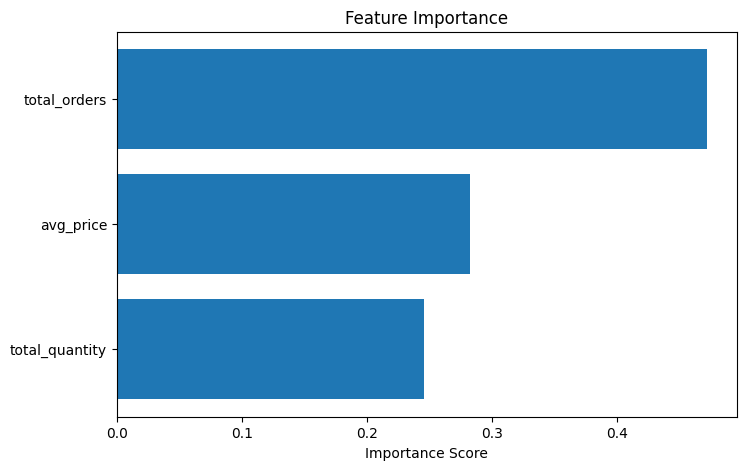

In [55]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

## Using OPTUNA

In [56]:
def objective(trial):

    params = {

        "n_estimators":
        trial.suggest_int(
            "n_estimators",
            100,
            500
        ),

        "max_depth":
        trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate":
        trial.suggest_float(
            "learning_rate",
            0.01,
            0.3
        ),

        "subsample":
        trial.suggest_float(
            "subsample",
            0.6,
            1.0
        ),

        "colsample_bytree":
        trial.suggest_float(
            "colsample_bytree",
            0.6,
            1.0
        ),

        "gamma":
        trial.suggest_float(
            "gamma",
            0,
            5
        ),

        "random_state":42,

        "eval_metric":"logloss"
    }

    model = XGBClassifier(**params)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score

In [57]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=20
)

[I 2026-05-26 15:30:54,559] A new study created in memory with name: no-name-e66c8970-5718-466d-b28d-c27ff8d50e93
[I 2026-05-26 15:30:56,394] Trial 0 finished with value: 0.7132461479116182 and parameters: {'n_estimators': 488, 'max_depth': 9, 'learning_rate': 0.2732668637189905, 'subsample': 0.6614762061512316, 'colsample_bytree': 0.8860048992512786, 'gamma': 2.1041961273840752}. Best is trial 0 with value: 0.7132461479116182.
[I 2026-05-26 15:30:57,379] Trial 1 finished with value: 0.7509660686047884 and parameters: {'n_estimators': 266, 'max_depth': 5, 'learning_rate': 0.15013700861685025, 'subsample': 0.9135727740877474, 'colsample_bytree': 0.7480206289563927, 'gamma': 4.894569136483246}. Best is trial 1 with value: 0.7509660686047884.
[I 2026-05-26 15:30:58,918] Trial 2 finished with value: 0.7201120462631349 and parameters: {'n_estimators': 362, 'max_depth': 6, 'learning_rate': 0.29093373161756353, 'subsample': 0.9053732748151235, 'colsample_bytree': 0.7484576514429335, 'gamma': 

In [58]:
study.best_params

{'n_estimators': 100,
 'max_depth': 4,
 'learning_rate': 0.20326002823542008,
 'subsample': 0.9937008122154225,
 'colsample_bytree': 0.6088042688997684,
 'gamma': 3.2303880653971646}

In [59]:
best_model = XGBClassifier(**study.best_params,random_state=42,eval_metric="logloss", scale_pos_weight=scale_weight)
best_model.fit( X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6088042688997684
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [60]:
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba( X_test)[:,1]

In [61]:
tuned_auc = roc_auc_score(y_test,y_prob_best)
tuned_acc = accuracy_score(y_test,y_pred_best)
tuned_f1 = f1_score(y_test,y_pred_best)
print("Tuned ROC-AUC:", tuned_auc)
print("Tuned Accuracy:", tuned_acc)
print("Tuned F1-Score:", tuned_f1)
print(classification_report(y_test,y_pred_best))

Tuned ROC-AUC: 0.7584366134089892
Tuned Accuracy: 0.6769964243146603
Tuned F1-Score: 0.624133148404993
              precision    recall  f1-score   support

           0       0.83      0.63      0.72       543
           1       0.53      0.76      0.62       296

    accuracy                           0.68       839
   macro avg       0.68      0.70      0.67       839
weighted avg       0.72      0.68      0.68       839



In [62]:
comparison_df = pd.DataFrame({

    "Model":[
        "Base XGBoost",
        "Optuna Tuned XGBoost"
    ],

    "ROC_AUC":[
        base_auc,
        tuned_auc
    ],

    "Accuracy":[
        0.65,
        tuned_acc
    ],

    "F1_Score":[
        0.65,
        tuned_f1
    ]
})

comparison_df

,Model,ROC_AUC,Accuracy,F1_Score
0,Base XGBoost,0.707011,0.650000,0.650000
1,Optuna Tuned XGBoost,0.758437,0.676996,0.624133


In [63]:
comparison_df.to_csv("../data/processed/model_comparison.csv",index=False)

In [64]:
importance_df.to_csv("../data/processed/feature_importance.csv",index=False)

In [65]:
with mlflow.start_run(run_name="optuna_tuned_xgboost"):
    mlflow.log_params(study.best_params)
    mlflow.log_metric("tuned_auc",tuned_auc)
    mlflow.log_metric("tuned_accuracy",tuned_acc)
    mlflow.log_metric("tuned_f1",tuned_f1)
    mlflow.log_artifact("../data/processed/model_comparison.csv")

In [66]:
import joblib

joblib.dump(
    best_model,
    "../models/tuned_xgboost.pkl"
)

['../models/tuned_xgboost.pkl']